# Feasibility of True Muonium Photoproduction

## Imports and Definitions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from importlib import reload

import helperFunctions as hf
from parameters import *

E in [43.5, 256.5] MeV
z in [-500, 1000] mm


## Parameters

In [2]:
# create a random number generator 
rng = np.random.default_rng(0)

## Event Preselection

In [3]:
tm = pd.read_pickle('data/tm.xz')

# select only TM created in the target with forward momentum
mask = (tm.pz>0) & (tm.z<targetThickness)
tm = tm.loc[mask].copy()

eleBG = pd.read_pickle('data/eleBG.xz')
posBG = pd.read_pickle('data/posBG.xz')

print(f'{len(tm)} true muonium events')
print(f'{len(eleBG)} electron events')
print(f'{len(posBG)} positron events')

55789 true muonium events
220469 electron events
200063 positron events


### Signal

In [4]:
# transverse and total momentum of the TM in [MeV]
tm['pt'] = np.sqrt(tm.px**2 + tm.py**2)
tm['ptot'] = np.sqrt(tm.px**2 + tm.py**2 + tm.pz**2)

# total energy of the TM in [MeV]
tm['Etot'] = np.sqrt(tm.ptot**2 + (2*muonMass_MeV)**2)

# opening angle from TM momenta in [rad]
tm['theta'] = np.arccos(tm.pz / tm.ptot)

# TM path length in target in [mm]
tm['lTarget'] = (targetThickness-tm.z) / np.cos(tm.theta)

# dissociation probability
tm['pDiss'] = 1 - np.exp(-tm.lTarget/dissociationLength)

# sample the escaping of the TM
tm['escape'] = tm.pDiss < rng.uniform(size=len(tm))

# beta factor of the TM atom
tm['beta'] = tm.ptot / tm.Etot

# gamma factor of the TM atom
tm['gamma'] = tm.Etot / (2*muonMass_MeV)

In [5]:
# sample the TM decay and calculate the signal hit info
ele, pos = hf.calcTM(tm, rng=rng)
print(f'accepted signal of {100*np.sum(ele.maskE & ele.maskZ & pos.maskE & pos.maskZ) / len(pos):.1f}%')

accepted signal of 84.2%


### Background

In [6]:
eleBG['ptot'] = np.sqrt(eleBG.px**2 + eleBG.py**2 + eleBG.pz**2)
posBG['ptot'] = np.sqrt(posBG.px**2 + posBG.py**2 + posBG.pz**2)

eleBG['Etot'] = np.sqrt(eleBG.ptot**2 + electronMass_MeV**2)
posBG['Etot'] = np.sqrt(posBG.ptot**2 + electronMass_MeV**2)

eleBG['maskZ'] = (eleBG.z>z_th_min) & (eleBG.z<z_th_max)
posBG['maskZ'] = (posBG.z>z_th_min) & (posBG.z<z_th_max)

eleBG['maskE'] = (eleBG.Etot>E_th_min) & (eleBG.Etot<E_th_max)
posBG['maskE'] = (posBG.Etot>E_th_min) & (posBG.Etot<E_th_max)

In [7]:
# combinatorial background
alphaBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='alpha')
ptBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='pt')
mInvBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='mInv')
dPhiBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='dPhi')

print(f'{len(alphaBG.flatten())} background events')
print(f'background reduction by {len(eleBG)*len(posBG) / len(alphaBG.flatten()):.1e}')

780640 background events
background reduction by 5.7e+04


### Results

In [8]:
# photon flux on target [1/s] 
photonFlux = 3.8e14 / 2

# number of simulated photons (nSim x nEvents x bias)
NSigSim = 1e1 * 1e9 * 1e6

# number of muon pairs in detector acceptance
nPairs = np.sum(tm.escape & ele.maskZ&ele.maskE & pos.maskZ&pos.maskE)

print('signal events:')
print(f'{nPairs:.2e} muon pair / {NSigSim:.0e} photons')
print(f'{nPairs / boundStateSuppression:.2e} TM atoms / {NSigSim:.0e} photons')

print('\nsignal requirements:')
print(f'{1 / (nPairs / boundStateSuppression / NSigSim):.2e} photons / TM')
print(f'{1 / (photonFlux * nPairs / boundStateSuppression / NSigSim / 1e7):.2e} BX / TM')

print('\nsignal rates:')
print(f'{nPairs / boundStateSuppression / NSigSim:.2e} TM / photon')
print(f'{photonFlux * nPairs / boundStateSuppression / NSigSim:.2e} TM / s')
print(f'{photonFlux * nPairs / boundStateSuppression / NSigSim / 1e7:.2e} TM / BX')
print(f'{3600 * 24 * photonFlux * nPairs / boundStateSuppression / NSigSim:.2e} TM / d')

signal events:
2.04e+04 muon pair / 1e+16 photons
3.33e-04 TM atoms / 1e+16 photons

signal requirements:
3.01e+19 photons / TM
1.58e+12 BX / TM

signal rates:
3.33e-20 TM / photon
6.32e-06 TM / s
6.32e-13 TM / BX
5.46e-01 TM / d


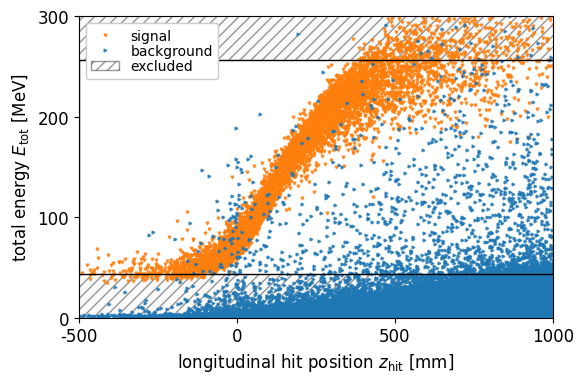

In [9]:
with plt.rc_context(regPlot):
    
    fig, ax = plt.subplots()
    
    ax.plot(ele[::10].hitZ, ele[::10].Etot, 'C1v', ms=2, alpha=0.8, label='signal')
    ax.plot(pos[::10].hitZ, pos[::10].Etot, 'C1v', ms=2, alpha=0.8)
    
    ax.plot(eleBG.z, eleBG.Etot, 'C0>', ms=2, alpha=0.8, label='background')
    ax.plot(posBG.z, posBG.Etot, 'C0>', ms=2, alpha=0.8)

    xtick = [-500, 0, 500, 1000]
    ytick = [0, 100, 200, 300]
    ax.set(xlim=(-500,1000), ylim=(0,photonEnergy), xticks=xtick, xticklabels=xtick, yticks=ytick, yticklabels=ytick)
    
    hf.add_hatched_exclusion(ax, x0=z_th_min, x1=z_th_max, y0=E_th_min, y1=E_th_max, hatch='///', label='excluded')
    
    ax.legend(loc='upper left')
    ax.set(xlabel=r'longitudinal hit position $z_\text{hit}$ [mm]', ylabel=r'total energy $E_\text{tot}$ [MeV]')

    fig.tight_layout()
    fig.savefig('plots/eventPreselection.png', dpi=300)
    fig.savefig('plots/eventPreselection.pdf')

    plt.show()

## Background Rejection

In [10]:
# number of e-/e+ after preselection
# slighly higher than in binned data
Ne = 1852329
Np = 1644504

print(f'Ne = {Ne}')
print(f'Np = {Np}')
print()
print(f'{Ne/4e13:.2e} e-/y')
print(f'{Np/4e13:.2e} e+/y')

Ne = 1852329
Np = 1644504

4.63e-08 e-/y
4.11e-08 e+/y


In [11]:
# load histogrammed data of signal and background
H4D_bkg = np.load('data/bkgH4D.npz')['H4D']
H4D_sig = np.load('data/sigH4D.npz')['H4D']

# load the binning of the histogrammed data
bins = np.load('data/bkgH4D.npz')
bins = [bins['alphaBins'], bins['dPhiBins'], bins['ptBins'], bins['mInvBins']]

In [12]:
# opening angle in [deg]
s0_low = 60; s0_high = 140
s0 = hf.bin_range(bins[0], low=s0_low, high=s0_high)

# azimuthal angle in [deg]
s1_low = 160; s1_high = 200
s1 = hf.bin_range(bins[1], low=s1_low, high=s1_high)

# transverse momentum in [MeV]
s2_low = 0; s2_high = 34
s2 = hf.bin_range(bins[2], low=s2_low, high=s2_high)

# invariant mass in [MeV]
s3_low = 190; s3_high = 230
s3 = hf.bin_range(bins[3], low=s3_low, high=s3_high)

ss = [s0,s1,s2,s3]

Hbkg = H4D_bkg[s0, s1, s2, s3]
Hsig = H4D_sig[s0, s1, s2, s3]

In [13]:
# true positive (signal that survives all cuts)
TP = Hsig.sum()

# false negative (rejected signal events)
FN = H4D_sig.sum() - TP

# accepted signal events / all signal events
sigEff = TP / (TP + FN)
print('SIGNAL')
print(f'signal efficiency:\t{sigEff:.2e}')

print('\nBACKGROUND')
print(f'simulated photons:\t{NSimBkg:.2e}')
print(f'simulated BG events:\t{Ne*Np:.2e}')

# false positive (background that survives all cuts)
FP = Hbkg.sum()
print(f'\nfalse positive:\t\t{FP:.2e}')

# true negative (rejected background events)
TN = Ne*Np - FP

# accepted background events / all background events
bkgEff = FP / (FP + TN)
print(f'background efficiency:\t{bkgEff:.2e}')
print(f'background rejection: \t{(1-bkgEff):.2e}')

if FP==0:
    print('\nno false positive from simulation!')
    print(f'upper limit on background efficiency: {3/TN:.1e} at 95% C.L.')

SIGNAL
signal efficiency:	9.44e-01

BACKGROUND
simulated photons:	4.00e+13
simulated BG events:	3.05e+12

false positive:		0.00e+00
background efficiency:	0.00e+00
background rejection: 	1.00e+00

no false positive from simulation!
upper limit on background efficiency: 9.8e-13 at 95% C.L.


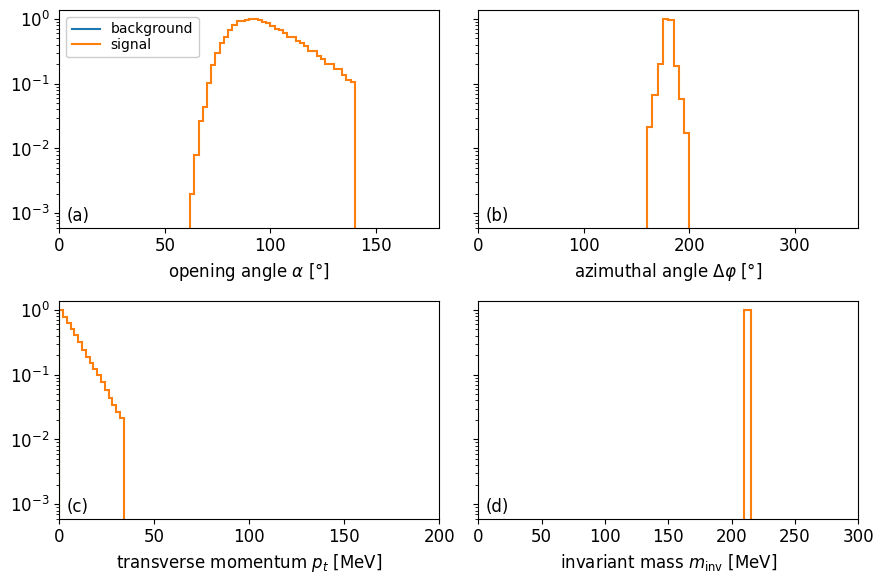

In [14]:
xlabels = [r'opening angle $\alpha$ [°]', 
           r'azimuthal angle $\Delta\varphi$ [°]', 
           r'transverse momentum $p_t$ [MeV]', 
           r'invariant mass $m_\text{inv}$ [MeV]']

subFigLabel = ['(a)', 
               '(b)', 
               '(c)', 
               '(d)']

with plt.rc_context(regPlot):

    fig, ax = plt.subplots(2, 2, sharey=True, figsize=(9,6))
    ax = ax.flatten()
    
    for k in range(4):
        
        H_bkg_tmp = Hbkg.sum(axis=tuple(i for i in range(Hbkg.ndim) if i!=k))
        if H_bkg_tmp.max() != 0:
            H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()
        ax[k].stairs(H_bkg_tmp, bins[k][ss[k].start:ss[k].stop+1], color='C0', lw=1.5, label='background')
    
        H_sig_tmp = Hsig.sum(axis=tuple(i for i in range(Hsig.ndim) if i!=k))
        if H_sig_tmp.max() != 0:
            H_sig_tmp = H_sig_tmp / H_sig_tmp.max()
        ax[k].stairs(H_sig_tmp, bins[k][ss[k].start:ss[k].stop+1], color='C1', lw=1.5, label='signal')

        ax[k].text(0.02, 0.03, subFigLabel[k], transform=ax[k].transAxes)
        ax[k].set(xlabel=xlabels[k], xlim=(bins[k][0], bins[k][-1]), yscale='log', ylim=(6e-4, None))

    ax[0].legend()

    fig.tight_layout()
    
    plt.show()

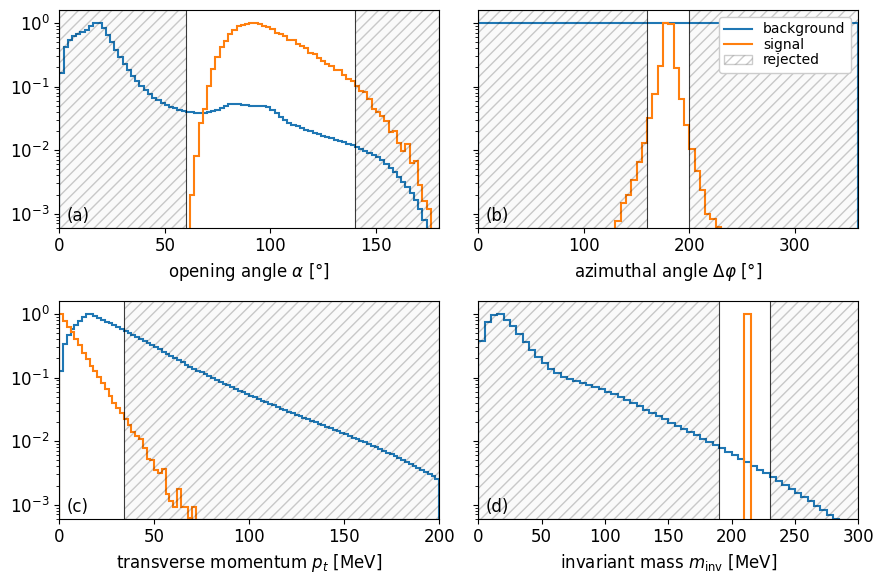

In [15]:
with plt.rc_context(regPlot):

    fig, ax = plt.subplots(2, 2, sharey=True, figsize=(9,6))
    ax = ax.flatten()
    
    for k in range(4):
        
        H_bkg_tmp = H4D_bkg.sum(axis=tuple(i for i in range(H4D_bkg.ndim) if i!=k))
        if H_bkg_tmp.max() != 0:
            H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()
        ax[k].stairs(H_bkg_tmp, bins[k], color='C0', lw=1.5, label='background')
    
        H_sig_tmp = H4D_sig.sum(axis=tuple(i for i in range(H4D_sig.ndim) if i!=k))
        if H_sig_tmp.max() != 0:
            H_sig_tmp = H_sig_tmp / H_sig_tmp.max()
        ax[k].stairs(H_sig_tmp, bins[k], color='C1', lw=1.5, label='signal')

        ax[k].text(0.02, 0.03, subFigLabel[k], transform=ax[k].transAxes)
        ax[k].set(xlabel=xlabels[k], xlim=(bins[k][0], bins[k][-1]), yscale='log', ylim=(6e-4, None))

    ax[0].axvline(s0_low, c='C5', ls='-', lw=0.5)
    ax[0].axvspan(bins[0][0], s0_low, color='C5', alpha=0.02, zorder=0)
    ax[0].axvspan(bins[0][0], s0_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[0].axvline(s0_high, c='C5', ls='-', lw=0.5)
    ax[0].axvspan(s0_high, bins[0][-1], color='C5', alpha=0.02, zorder=0)
    ax[0].axvspan(s0_high, bins[0][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)
    
    ax[1].axvline(s1_low, c='C5', ls='-', lw=0.5)
    ax[1].axvspan(bins[1][0], s1_low, color='C5', alpha=0.02, zorder=0)
    ax[1].axvspan(bins[1][0], s1_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[1].axvline(s1_high, c='C5', ls='-', lw=0.5)
    ax[1].axvspan(s1_high, bins[1][-1], color='C5', alpha=0.02, zorder=0)
    ax[1].axvspan(s1_high, bins[1][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)

    ax[2].axvline(s2_low, c='C5', ls='-', lw=0.5)
    ax[2].axvspan(bins[2][0], s2_low, color='C5', alpha=0.02, zorder=0)
    ax[2].axvspan(bins[2][0], s2_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[2].axvline(s2_high, c='C5', ls='-', lw=0.5)
    ax[2].axvspan(s2_high, bins[2][-1], color='C5', alpha=0.02, zorder=0)
    ax[2].axvspan(s2_high, bins[2][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')

    ax[3].axvline(s3_low, c='C5', ls='-', lw=0.5)
    ax[3].axvspan(bins[3][0], s3_low, color='C5', alpha=0.02, zorder=0)
    ax[3].axvspan(bins[3][0], s3_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[3].axvline(s3_high, c='C5', ls='-', lw=0.5)
    ax[3].axvspan(s3_high, bins[3][-1], color='C5', alpha=0.02, zorder=0)
    ax[3].axvspan(s3_high, bins[3][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)   

    ax[1].legend(loc='upper right')

    fig.tight_layout()
    fig.savefig('plots/eventDistributions.png', dpi=300)
    fig.savefig('plots/eventDistributions.pdf')
    
    plt.show()

## Lifetime

### Example Distributions

In [16]:
# test lifetimes [s]
taus = np.array([1.81, 1.41, 2.21]) * 1e-12  

# vz bins [mm]
bins = np.arange(0.5, 8+0.1, 0.1)

templates = hf.make_templates(
    tm,
    taus,
    N_template=500_000,
    smearing=mu3e_smearing,
    rng=rng
)

Making template for tau = 1.81 ps
more elements selected than in dataset
Making template for tau = 1.41 ps
more elements selected than in dataset
Making template for tau = 2.21 ps
more elements selected than in dataset


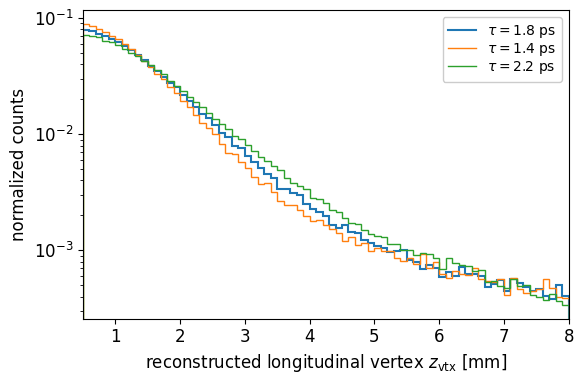

In [17]:
normalize=True

with plt.rc_context(regPlot):
    
    fig, ax = plt.subplots()

    for tau, vz in templates.items():
        counts, edges = np.histogram(vz, bins=bins)
        if normalize:
            counts = counts / counts.sum()
        ax.stairs(counts, edges, lw=1.5 if tau==1.81e-12 else 1, label=fr"$\tau={tau*1e12:.1f}$ ps")
    
    ax.set(xlabel=r'reconstructed longitudinal vertex $z_{\mathrm{vtx}}$ [mm]', xlim=(bins[0], bins[-1]),
           ylabel='normalized counts' if normalize else 'counts', yscale='log')
    
    ax.legend(loc='upper right')

    fig.tight_layout()
    fig.savefig('plots/lifetime.png', dpi=300)
    fig.savefig('plots/lifetime.pdf')
    
    plt.show()

### Full Analysis

In [18]:
# test lifetimes [s]
taus = np.arange(1.2, 2.4+0.1, 0.05) * 1e-12  

# vz bins [mm]
bins = np.arange(0.5, 8+0.1, 0.1)

In [19]:
# make templates once
templates = hf.make_templates(
    tm,
    taus,
    N_template=500_000,
    rng=rng
)

Making template for tau = 1.20 ps
more elements selected than in dataset
Making template for tau = 1.25 ps
more elements selected than in dataset
Making template for tau = 1.30 ps
more elements selected than in dataset
Making template for tau = 1.35 ps
more elements selected than in dataset
Making template for tau = 1.40 ps
more elements selected than in dataset
Making template for tau = 1.45 ps
more elements selected than in dataset
Making template for tau = 1.50 ps
more elements selected than in dataset
Making template for tau = 1.55 ps
more elements selected than in dataset
Making template for tau = 1.60 ps
more elements selected than in dataset
Making template for tau = 1.65 ps
more elements selected than in dataset
Making template for tau = 1.70 ps
more elements selected than in dataset
Making template for tau = 1.75 ps
more elements selected than in dataset
Making template for tau = 1.80 ps
more elements selected than in dataset
Making template for tau = 1.85 ps
more elements sel

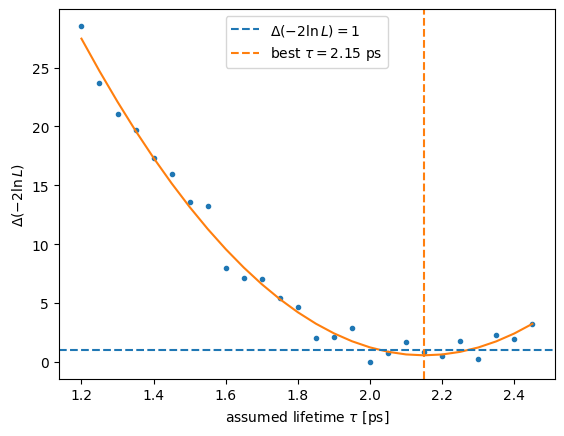

In [20]:
# show example NLL curve
_ = hf.expected_precision(
    tm,
    templates, bins,
    tau_true=otmTau,
    N_data=1000,
    N_toys=1,
    smearing=mu3e_smearing,
    rng=rng, 
    verbose=2
)

In [21]:
N = 1400

fitted = hf.expected_precision(
    tm, 
    templates, bins,
    tau_true=otmTau,
    N_data=N,
    N_toys=200,
    smearing=mu3e_smearing,
    rng=rng
)

fitted_mean = fitted.mean()
fitted_std = fitted.std(ddof=1)

print(
    f"N = {N:6d}: "
    f"tau = {1e12*fitted_mean:.3f} ± {1e12*fitted_std:.3f} ps "
    f"({100*fitted_std/otmTau:.1f}%)"
)

N =   1400: tau = 1.839 ± 0.157 ps (8.7%)


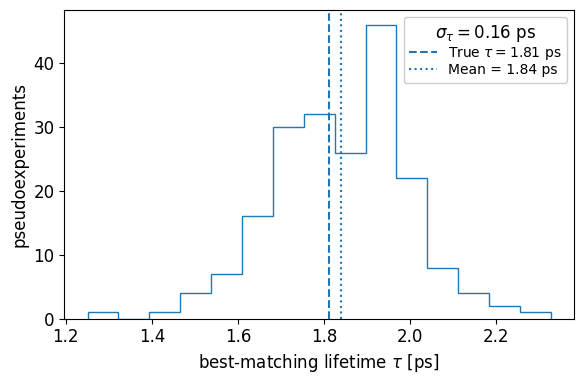

In [22]:
with plt.rc_context(regPlot):
    
    fig, ax = plt.subplots()
    ax.hist(fitted * 1e12, bins=15, histtype="step")
    ax.axvline(otmTau * 1e12, linestyle="--", label=fr"True $\tau={otmTau*1e12:.2f}$ ps")

    mean = np.mean(fitted)
    sigma = np.std(fitted, ddof=1)

    ax.axvline(mean * 1e12, linestyle=":", label=fr"Mean = {mean*1e12:.2f} ps")
    ax.set(xlabel=r'best-matching lifetime $\tau$ [ps]', ylabel='pseudoexperiments')
    ax.legend(title=fr"$\sigma_\tau={sigma*1e12:.2f}$ ps")
    fig.tight_layout()
    plt.show()

In [23]:
# 5) Event-count scan
N_data = np.array([700, 800, 900, 1000, 1100, 1200, 1300, 1400])

results = []
for N in N_data:

    fitted = hf.expected_precision(
        tm, 
        templates, bins,
        tau_true=otmTau,
        N_data=N,
        N_toys=200,
        smearing=mu3e_smearing,
        rng=rng
    )
    results.append(fitted)

    fitted_mean = fitted.mean()
    fitted_std = fitted.std(ddof=1)

    print(
        f"N = {N:6d}: "
        f"tau = {1e12*fitted_mean:.3f} ± {1e12*fitted_std:.3f} ps "
        f"({100*fitted_std/otmTau:.1f}%)"
    )
    
results = np.array(results)

N =    700: tau = 1.830 ± 0.220 ps (12.2%)
N =    800: tau = 1.811 ± 0.187 ps (10.3%)
N =    900: tau = 1.823 ± 0.195 ps (10.8%)
N =   1000: tau = 1.817 ± 0.176 ps (9.7%)
N =   1100: tau = 1.825 ± 0.177 ps (9.8%)
N =   1200: tau = 1.841 ± 0.174 ps (9.6%)
N =   1300: tau = 1.843 ± 0.168 ps (9.3%)
N =   1400: tau = 1.804 ± 0.158 ps (8.7%)


10% crossing: 1026 events


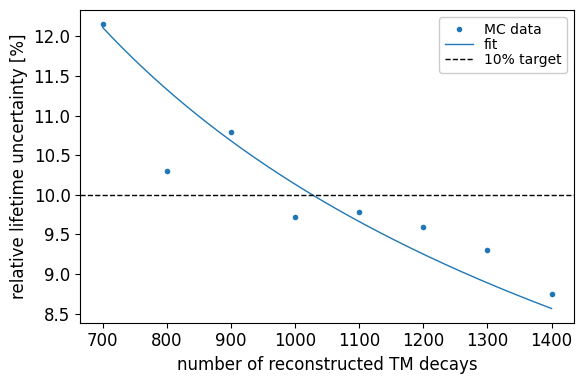

In [24]:
rel = results.std(axis=1, ddof=1)/otmTau

# fit rel_unc = a / sqrt(N)
a = np.mean(rel * np.sqrt(N_data))
N_10 = (a / 0.10)**2
print(f'10% crossing: {int(N_10)} events')

xfit = np.linspace(N_data[0], N_data[-1], 1001)
yfit = 100 * a / np.sqrt(xfit)

with plt.rc_context(regPlot):
    
    fig, ax = plt.subplots()
    
    ax.plot(N_data, 100*rel, 'C0.', label='MC data')
    ax.plot(xfit, yfit, 'C0-', lw=1, label='fit')
    ax.axhline(10, ls="--", lw=1, c='C5', label="10% target")
    
    ax.set(xlabel='number of reconstructed TM decays', ylabel='relative lifetime uncertainty [%]')
    ax.legend()
    
    fig.tight_layout()
    fig.savefig('plots/lifetimeUncertainty.png', dpi=300)
    fig.savefig('plots/lifetimeUncertainty.pdf')
    
    plt.show()